# Exploration — Données brutes capteurs

| Fichier | Contenu |
|---|---|
| `data/Données_brutes/DataPhase1.mat` | 42 sujets × 75 600 timesteps × 18 signaux — Phase 1 |
| `data/Données_brutes/DataPhase2.mat` | 42 sujets × 75 600 timesteps × 18 signaux — Phase 2 |

## 0. Imports et configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from data_utils import (
    load_raw_data, get_subject_dataframe,
    RAW_SIGNAL_COLS, SAMPLING_RATE
)

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Chargement des données

In [2]:
subject_ids_p1, data_p1 = load_raw_data(phase=1)
subject_ids_p2, data_p2 = load_raw_data(phase=2)

print(f'Phase 1 : {len(subject_ids_p1)} sujets, shape={data_p1.shape}')
print(f'Phase 2 : {len(subject_ids_p2)} sujets, shape={data_p2.shape}')
print(f'\nIdentifiants sujets Phase 1 : {subject_ids_p1}')
print(f'\nSignaux disponibles ({len(RAW_SIGNAL_COLS)}) :')
for i, col in enumerate(RAW_SIGNAL_COLS):
    print(f'  [{i:2d}] {col}')

Phase 1 : 42 sujets, shape=(42, 4)
Phase 2 : 42 sujets, shape=(42, 4)

Identifiants sujets Phase 1 : ['136KD7', '0933', '7180bt', '22009611', 'ab0710', 'am3001', 'AP1133', 'BD1510', 'BM1997', 'CC1969', 'CH1308', 'CL1901', 'CM8976', 'CP1234', 'DZ1233', 'EL5421', 'EM1912', 'FC1997', 'GE2247', 'GG34', 'JO1213', 'JO8794', 'JP1824', 'JU1302', 'ld4024', 'LD5924', 'Li2005', 'LN0908', 'M4S5', 'MD2001', 'MM2024', 'MO2724', 'NB1934', 'NT1234', 'PC1301', 'RC1056', 'rl2704', 'RU3300', 'TE2024', 'tt3912', 'VA2211', 'yz1234']

Signaux disponibles (18) :
  [ 0] Time
  [ 1] HMDPosX
  [ 2] HMDPosY
  [ 3] HMDPosZ
  [ 4] RotX
  [ 5] RotY
  [ 6] RotZ
  [ 7] Suggested Rotation X
  [ 8] Suggested Rotation Y
  [ 9] Suggested Rotation Z
  [10] Left Pupil Diameter
  [11] Right Pupil Diameter
  [12] X gaze direction
  [13] Y gaze direction
  [14] Confidence
  [15] isBoat
  [16] X World Position
  [17] Y World Position


## 2. Aperçu d'un sujet

In [3]:
df_example = get_subject_dataframe(data_p1, subject_idx=0)
print(f'Sujet : {subject_ids_p1[0]}')
print(f'Durée : {df_example["Time"].iloc[-1]:.1f} s ({df_example["Time"].iloc[-1]/60:.1f} min)')
print(f'Shape : {df_example.shape}')
df_example[RAW_SIGNAL_COLS[1:]].round(2)

Sujet : 136KD7
Durée : 840.0 s (14.0 min)
Shape : (75600, 18)


,HMDPosX,HMDPosY,HMDPosZ,RotX,RotY,RotZ,Suggested Rotation X,Suggested Rotation Y,Suggested Rotation Z,Left Pupil Diameter,Right Pupil Diameter,X gaze direction,Y gaze direction,Confidence,isBoat,X World Position,Y World Position
Time (s),,,,,,,,,,,,,,,,,
0.000,-0.14,1.14,0.37,0.97,3.40,1.45,0.00,0.00,0.00,4.15,4.22,-0.05,-0.24,0.97,NaN,NaN,NaN
0.011,-0.14,1.14,0.37,0.97,3.40,1.45,0.86,-3.91,4.53,4.16,4.22,-0.05,-0.24,0.97,NaN,NaN,NaN
0.015,-0.14,1.14,0.37,0.97,3.40,1.45,0.86,-3.91,4.53,4.16,4.23,-0.05,-0.24,0.97,NaN,NaN,NaN
0.044,-0.15,1.13,0.36,1.62,5.05,0.74,0.86,-3.91,4.53,4.17,4.24,-0.05,-0.24,0.97,1.0,0.0,0.0
0.049,-0.15,1.13,0.36,1.62,5.05,0.74,0.91,-3.90,4.26,4.17,4.24,-0.05,-0.24,0.97,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
839.948,-0.09,1.11,0.35,5.54,-13.79,1.55,0.66,-3.94,5.50,4.50,4.65,-0.13,-0.12,0.98,0.0,-5.0,-2.0
839.962,-0.09,1.11,0.35,5.56,-13.55,1.53,0.66,-3.94,5.50,4.49,4.65,-0.13,-0.12,0.98,0.0,-5.0,-2.0
839.977,-0.09,1.11,0.35,5.59,-13.35,1.49,0.75,-3.93,5.11,4.49,4.64,-0.13,-0.12,0.98,0.0,-5.0,-2.0


## 3. Visualisation des signaux principaux (sujet 0, Phase 1)

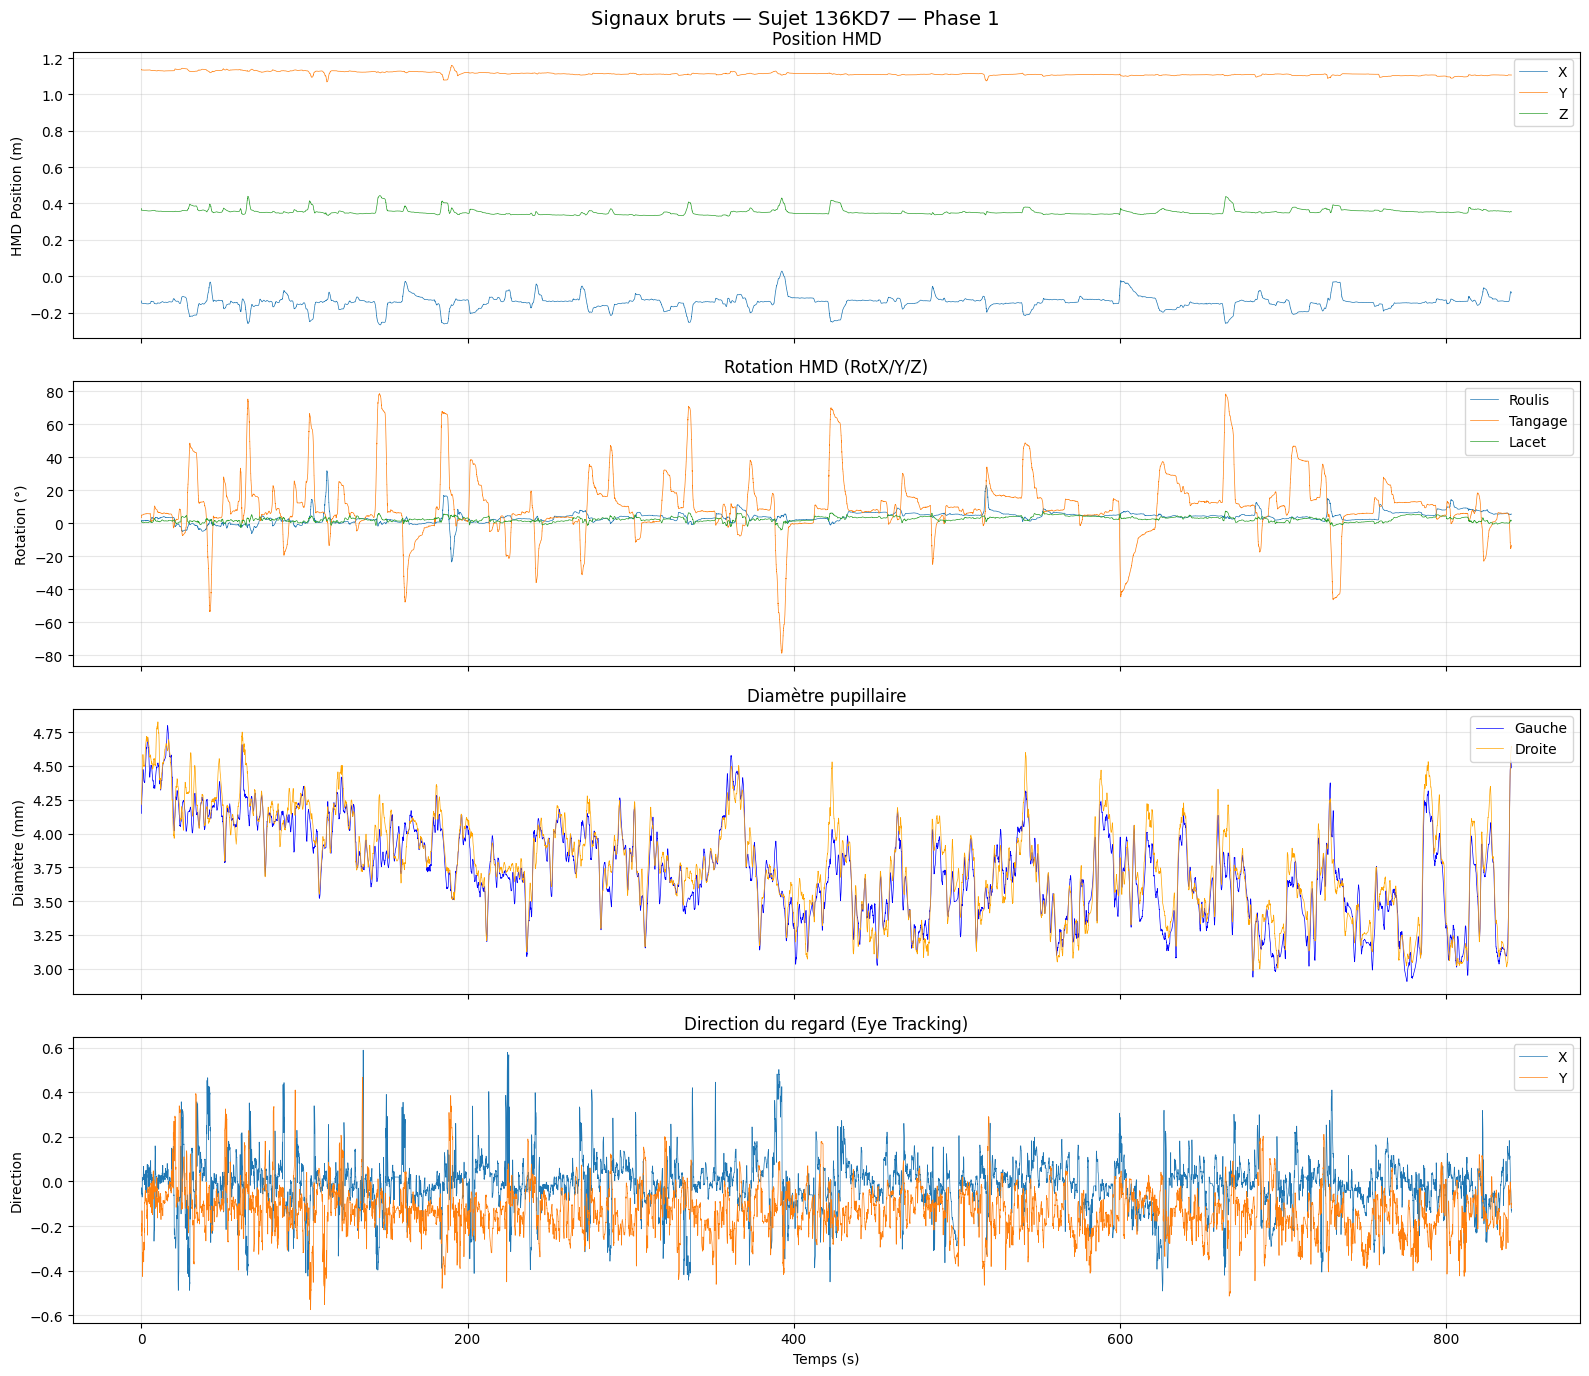

In [4]:
df = df_example
t = df['Time'].values

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
fig.suptitle(f'Signaux bruts — Sujet {subject_ids_p1[0]} — Phase 1', fontsize=14, y=0.98)

axes[0].plot(t, df['HMDPosX'], label='X', lw=0.5)
axes[0].plot(t, df['HMDPosY'], label='Y', lw=0.5)
axes[0].plot(t, df['HMDPosZ'], label='Z', lw=0.5)
axes[0].set_ylabel('HMD Position (m)')
axes[0].legend(loc='upper right')
axes[0].set_title('Position HMD')

axes[1].plot(t, df['RotX'], label='Roulis', lw=0.5)
axes[1].plot(t, df['RotY'], label='Tangage', lw=0.5)
axes[1].plot(t, df['RotZ'], label='Lacet', lw=0.5)
axes[1].set_ylabel('Rotation (°)')
axes[1].legend(loc='upper right')
axes[1].set_title('Rotation HMD (RotX/Y/Z)')

axes[2].plot(t, df['Left Pupil Diameter'], label='Gauche', lw=0.5, color='blue')
axes[2].plot(t, df['Right Pupil Diameter'], label='Droite', lw=0.5, color='orange')
axes[2].set_ylabel('Diamètre (mm)')
axes[2].legend(loc='upper right')
axes[2].set_title('Diamètre pupillaire')

axes[3].plot(t, df['X gaze direction'], label='X', lw=0.5)
axes[3].plot(t, df['Y gaze direction'], label='Y', lw=0.5)
axes[3].set_ylabel('Direction')
axes[3].set_xlabel('Temps (s)')
axes[3].legend(loc='upper right')
axes[3].set_title('Direction du regard (Eye Tracking)')

plt.tight_layout()
plt.show()

## 4. Variabilité inter-sujets, Phase 1

Calcul des statistiques inter-sujets Phase 1...
DataFrame stats inter-sujets : (42, 34)


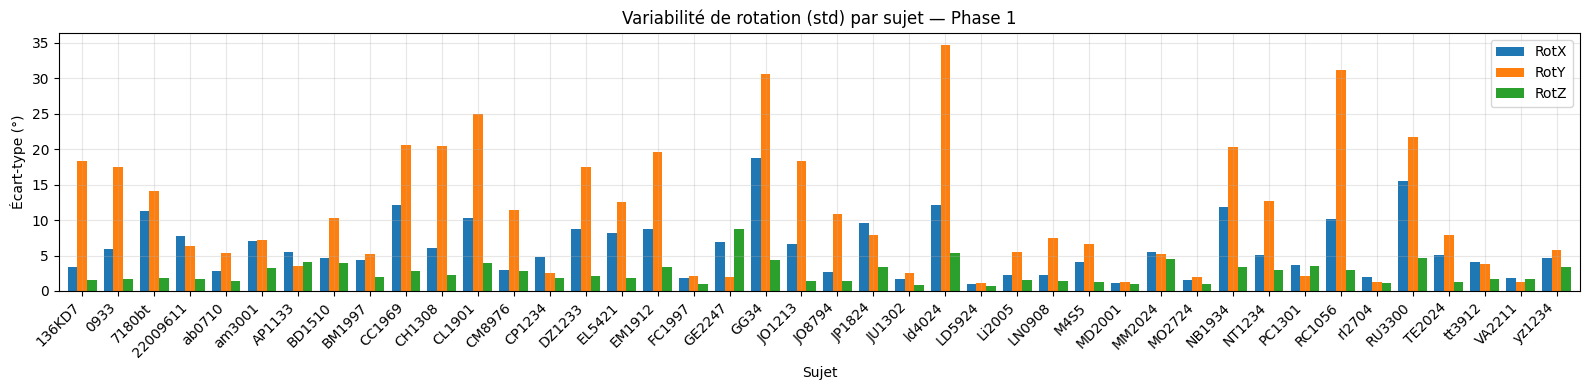

In [5]:
print('Calcul des statistiques inter-sujets Phase 1...')

stats_list = []
for i, sid in enumerate(subject_ids_p1):
    ts = data_p1[i, 2]  # (75600, 18)
    row = {'sujet': sid}
    for j, col in enumerate(RAW_SIGNAL_COLS[1:], start=1):
        row[f'{col}_mean'] = np.nanmean(ts[:, j])
        row[f'{col}_std'] = np.nanstd(ts[:, j])
    stats_list.append(row)

df_stats = pd.DataFrame(stats_list).set_index('sujet')
print(f'DataFrame stats inter-sujets : {df_stats.shape}')

rot_cols_std = ['RotX_std', 'RotY_std', 'RotZ_std']
fig, ax = plt.subplots(figsize=(16, 4))
df_stats[rot_cols_std].plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Variabilité de rotation (std) par sujet — Phase 1')
ax.set_xlabel('Sujet')
ax.set_ylabel('Écart-type (°)')
ax.legend(['RotX', 'RotY', 'RotZ'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Distribution des diamètres pupillaires, Phase 1

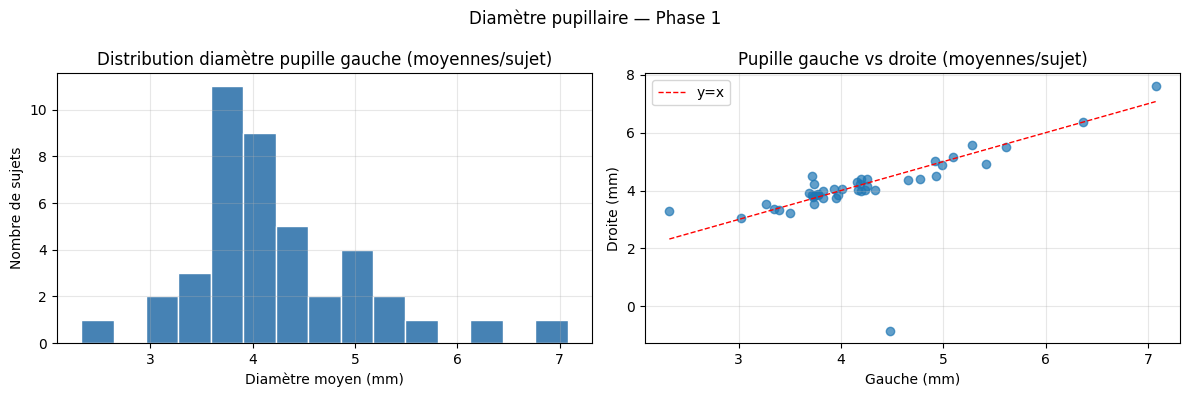

In [6]:
left_means = [np.nanmean(data_p1[i, 2][:, 10]) for i in range(42)]
right_means = [np.nanmean(data_p1[i, 2][:, 11]) for i in range(42)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(left_means, bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution diamètre pupille gauche (moyennes/sujet)')
axes[0].set_xlabel('Diamètre moyen (mm)')
axes[0].set_ylabel('Nombre de sujets')

axes[1].scatter(left_means, right_means, alpha=0.7)
axes[1].plot([min(left_means), max(left_means)], [min(left_means), max(left_means)],
             'r--', lw=1, label='y=x')
axes[1].set_title('Pupille gauche vs droite (moyennes/sujet)')
axes[1].set_xlabel('Gauche (mm)')
axes[1].set_ylabel('Droite (mm)')
axes[1].legend()

plt.suptitle('Diamètre pupillaire — Phase 1', fontsize=12)
plt.tight_layout()
plt.show()